In [1]:
import numpy as np


def differential_importance(
    model,
    x0,
    h=1e-6
):
    """
    Differential importance measure (DIM)
    using numerical differentiation.

    Assumption:

        dx_i / x_i^0 = constant

    so that

        d_i y = (∂y/∂x_i) * x_i^0

    and

        D_i = d_i y / Σ d_i y
    """

    x0 = np.asarray(x0, dtype=float)

    d = len(x0)

    grad = np.zeros(d)

    # Central finite differences
    for i in range(d):

        xp = x0.copy()
        xm = x0.copy()

        xp[i] += h
        xm[i] -= h

        grad[i] = (
            model(xp)
            - model(xm)
        ) / (2*h)

    differential_contributions = grad * x0

    total = np.sum(differential_contributions)

    DIM = differential_contributions / total

    return {
        "gradient": grad,
        "differential_contributions":
            differential_contributions,
        "DIM": DIM
    }

In [4]:
def model(x):
    """
    Ishigami function.
    """

    a = 7
    b = 0.1

    return (
        np.sin(x[0])
        + a * np.sin(x[1])**2
        + b * x[2]**4 * np.sin(x[0])
    )

In [5]:
def plot_DIM(result, variable_names=None):

    import matplotlib.pyplot as plt
    import numpy as np

    DIM = np.asarray(result["DIM"])

    d = len(DIM)

    if variable_names is None:
        variable_names = [
            f"x{i+1}"
            for i in range(d)
        ]

    idx = np.argsort(np.abs(DIM))[::-1]

    DIM = DIM[idx]
    names = [variable_names[i] for i in idx]

    y = np.arange(d)

    plt.figure(figsize=(8,4))

    plt.barh(
        y,
        DIM,
        color="steelblue"
    )

    plt.axvline(
        0,
        color="black"
    )

    plt.yticks(y, names)

    plt.xlabel("Differential importance")
    plt.title("Differential Importance Measure")

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

Gradient
[0.59433254 6.36508199 0.33658839]

DIM
[0.08146002 0.87240672 0.04613326]


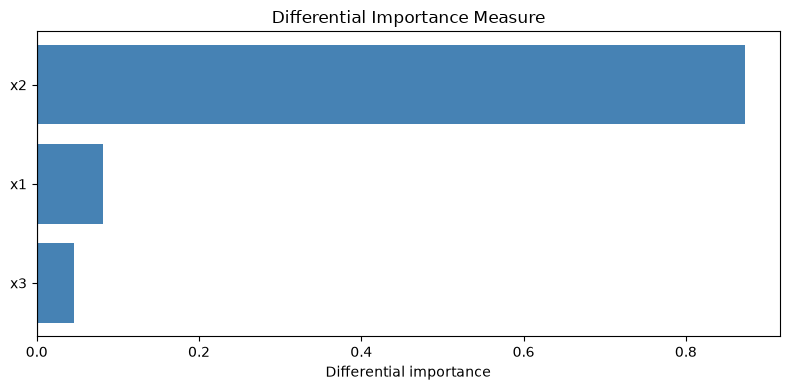

In [6]:
x0 = np.array([1.0,1.0,1.0])

result = differential_importance(
    model,
    x0
)

print("Gradient")
print(result["gradient"])

print("\nDIM")
print(result["DIM"])

plot_DIM(
    result,
    variable_names=["x1","x2","x3"]
)